# Montréal Gas Price — Inference & Budget Estimator
**Input:** `montreal_gas_ml_ready.csv`, `model_ridge.pkl`, `model_lgbm.pkl`, `scaler.pkl`  
**Goal:** Predict gas prices up to 4 weeks ahead and estimate monthly budget

**Pipeline:**
1. Load models and data
2. 4-week recursive price range forecast
3. Weekly price range summary
4. Monthly budget estimator (based on last month's spend)
5. Export forecast to CSV
6. Auto-retraining setup

**Auto-retraining:** Run `scheduler.py` once in a terminal to automatically retrain daily.

## 0. Imports

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib joblib schedule lightgbm scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import json
import os

PLOTS_DIR  = '../plots'
DATA_DIR   = '../Data'
WEBAPP_DIR = '../webapp'
from datetime import datetime, timedelta
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

print('Ready.')

Ready.


## 1. Load models and data

In [3]:
# Load trained models saved at the end of Notebook 3
ridge  = joblib.load(os.path.join(WEBAPP_DIR, 'model_ridge.pkl'))
lgbm   = joblib.load(os.path.join(WEBAPP_DIR, 'model_lgbm.pkl'))
scaler = joblib.load(os.path.join(WEBAPP_DIR, 'scaler.pkl'))

print('Models loaded:')
print('  model_ridge.pkl  ✓')
print('  model_lgbm.pkl   ✓')
print('  scaler.pkl       ✓')

# Show last retrain time if available
if os.path.exists(os.path.join(WEBAPP_DIR, 'retrain_log.json')):
    with open(os.path.join(WEBAPP_DIR, 'retrain_log.json')) as f:
        log = json.load(f)
    print(f'\n  Last retrained : {log["last_retrain"]}')
    print(f'  Training rows  : {log["training_rows"]}')
    print(f'  Data up to     : {log["data_end"]}')
else:
    print('\n  No retrain log found — run scheduler.py to enable auto-retraining')

Models loaded:
  model_ridge.pkl  ✓
  model_lgbm.pkl   ✓
  scaler.pkl       ✓

  No retrain log found — run scheduler.py to enable auto-retraining


In [4]:
# Load dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'montreal_gas_ml_ready.csv'))
date_col = 'date' if 'date' in df.columns else 'Unnamed: 0'
df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col)
df.index.name = 'date'

# Must match the EXCLUDE list used in Notebook 3 exactly
EXCLUDE  = ['gas_price', 'wti_usd', 'cadusd', 'wti_cad', 'target_price', 'target_change']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

today_date  = df.index[-1]
today_price = df['gas_price'].iloc[-1]

print(f'Dataset loaded  : {len(df):,} rows')
print(f'Data up to      : {today_date.date()}')
print(f"Today's price   : {today_price:.1f} ¢/L")

Dataset loaded  : 2,523 rows
Data up to      : 2026-03-31
Today's price   : 193.1 ¢/L


## 2. 4-week recursive price range forecast

We forecast 28 days ahead using **recursive forecasting** — each predicted price becomes
the input for the next day's prediction.

Since errors compound over time, we build a **confidence band** that widens with each step:
- The band uses recent price volatility (std of last 30 days) scaled by the square root
  of days ahead — a standard technique for time series uncertainty.
- Day 1 predictions are tight, day 28 are wide — honest about what the model can and cannot know.

In [5]:
N_DAYS = 28

# Recent volatility used to build widening confidence bands
recent_std    = df['gas_price'].iloc[-30:].std()

forecast_rows = []
current_df    = df.copy()

for step in range(1, N_DAYS + 1):
    latest = current_df.iloc[[-1]]
    X      = latest[FEATURES]

    # Ensemble prediction (Ridge + LightGBM average)
    pred_ridge    = ridge.predict(scaler.transform(X))[0]
    pred_lgbm     = lgbm.predict(X)[0]
    pred_ensemble = (pred_ridge + pred_lgbm) / 2

    # Widening confidence band
    band      = 1.5 * recent_std * np.sqrt(step)
    pred_low  = pred_ensemble - band
    pred_high = pred_ensemble + band

    forecast_date = latest.index[0] + timedelta(days=1)

    forecast_rows.append({
        'date'     : forecast_date,
        'pred_low' : round(pred_low,  2),
        'pred_mid' : round(pred_ensemble, 2),
        'pred_high': round(pred_high, 2),
        'step'     : step
    })

    # Roll lags forward using the new prediction
    new_row = latest.copy()
    new_row.index             = [forecast_date]
    new_row['gas_lag_21']     = new_row['gas_lag_10']
    new_row['gas_lag_10']     = new_row['gas_lag_5']
    new_row['gas_lag_5']      = new_row['gas_lag_3']
    new_row['gas_lag_3']      = new_row['gas_lag_2']
    new_row['gas_lag_2']      = new_row['gas_lag_1']
    new_row['gas_lag_1']      = pred_ensemble
    new_row['gas_chg_1']      = pred_ensemble - float(latest['gas_lag_1'].iloc[0])
    new_row['day_of_week']    = forecast_date.dayofweek
    new_row['month']          = forecast_date.month
    # Update rolling means incrementally
    new_row['gas_roll_mean_5']  = (float(latest['gas_roll_mean_5'].iloc[0])  * 4  + pred_ensemble) / 5
    new_row['gas_roll_mean_10'] = (float(latest['gas_roll_mean_10'].iloc[0]) * 9  + pred_ensemble) / 10
    new_row['gas_roll_mean_21'] = (float(latest['gas_roll_mean_21'].iloc[0]) * 20 + pred_ensemble) / 21

    current_df = pd.concat([current_df, new_row])

forecast_df = pd.DataFrame(forecast_rows).set_index('date')

print(f'28-day forecast: {(today_date + timedelta(days=1)).date()} → {forecast_df.index[-1].date()}')
print()
print(forecast_df[['pred_low', 'pred_mid', 'pred_high']].to_string())

28-day forecast: 2026-04-01 → 2026-04-28

            pred_low  pred_mid  pred_high
date                                     
2026-04-01    167.52    192.06     216.59
2026-04-02    155.94    190.65     225.35
2026-04-03    148.12    190.62     233.12
2026-04-04    142.69    191.77     240.84
2026-04-05    137.32    192.19     247.06
2026-04-06    131.99    192.09     252.20
2026-04-07    127.79    192.71     257.63
2026-04-08    123.39    192.79     262.19
2026-04-09    119.43    193.04     266.66
2026-04-10    115.46    193.06     270.65
2026-04-11    111.69    193.07     274.45
2026-04-12    108.11    193.11     278.11
2026-04-13    104.62    193.09     281.56
2026-04-14    101.74    193.55     285.37
2026-04-15     98.39    193.43     288.46
2026-04-16     95.43    193.59     291.74
2026-04-17     92.42    193.59     294.77
2026-04-18     89.28    193.38     297.49
2026-04-19     86.46    193.42     300.38
2026-04-20     83.55    193.28     303.02
2026-04-21     81.23    193.68    

## 3. Weekly price range summary

Daily forecasts aggregated into 4 weekly ranges — easier to read and more honest
about uncertainty beyond the first few days.

In [6]:
forecast_df['week'] = ((forecast_df['step'] - 1) // 7) + 1

weekly = forecast_df.groupby('week').agg(
    date_from = ('pred_mid', lambda x: forecast_df.loc[x.index[0],  :].name.date()),
    date_to   = ('pred_mid', lambda x: forecast_df.loc[x.index[-1], :].name.date()),
    low       = ('pred_low',  'min'),
    mid       = ('pred_mid',  'mean'),
    high      = ('pred_high', 'max')
).round(1)

print('=== 4-Week Price Range Forecast ===')
print(f"Today's price: {today_price:.1f} ¢/L")
print()
for week, row in weekly.iterrows():
    print(f'  Week {week} ({row.date_from} → {row.date_to})')
    print(f'    Range : {row.low:.1f} – {row.high:.1f} ¢/L')
    print(f'    Mid   : {row.mid:.1f} ¢/L')
    print()

=== 4-Week Price Range Forecast ===
Today's price: 193.1 ¢/L

  Week 1 (2026-04-01 → 2026-04-07)
    Range : 127.8 – 257.6 ¢/L
    Mid   : 191.7 ¢/L

  Week 2 (2026-04-08 → 2026-04-14)
    Range : 101.7 – 285.4 ¢/L
    Mid   : 193.1 ¢/L

  Week 3 (2026-04-15 → 2026-04-21)
    Range : 81.2 – 306.1 ¢/L
    Mid   : 193.5 ¢/L

  Week 4 (2026-04-22 → 2026-04-28)
    Range : 64.0 – 323.7 ¢/L
    Mid   : 193.7 ¢/L



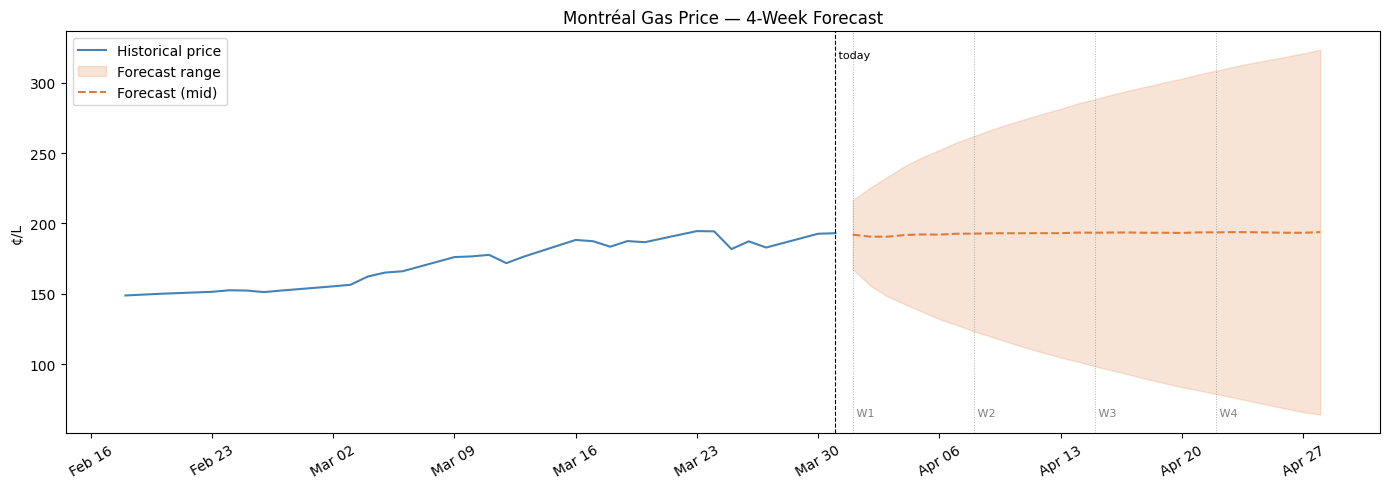

In [7]:
# Visualise the 4-week forecast with historical context
recent_prices = df['gas_price'].iloc[-30:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(recent_prices.index, recent_prices.values,
        color='steelblue', linewidth=1.5, label='Historical price')
ax.fill_between(forecast_df.index,
                forecast_df['pred_low'], forecast_df['pred_high'],
                alpha=0.2, color='#e07b39', label='Forecast range')
ax.plot(forecast_df.index, forecast_df['pred_mid'],
        color='#e07b39', linewidth=1.5, linestyle='--', label='Forecast (mid)')

# Week dividers
for w in range(1, 5):
    week_start = forecast_df[forecast_df['week'] == w].index[0]
    ax.axvline(week_start, color='gray', linestyle=':', linewidth=0.7, alpha=0.6)
    ax.text(week_start, forecast_df['pred_low'].min() - 1, f' W{w}', fontsize=8, color='gray')

ax.axvline(today_date, color='black', linestyle='--', linewidth=0.8)
ax.text(today_date, forecast_df['pred_high'].max(), ' today', fontsize=8, va='top')

ax.set_title('Montréal Gas Price — 4-Week Forecast')
ax.set_ylabel('¢/L')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'forecast_4week.png'), dpi=150)
plt.show()

## 4. Monthly budget estimator

Enter how much you **spent on gas last month** in CAD dollars.

We back-calculate your implied litres consumed using last month's average price,
then apply next month's forecast price range to estimate your upcoming budget.

**Formula:**
```
implied_litres = last_month_spend / (last_month_avg_price / 100)
budget         = implied_litres   × (forecast_price / 100)
```

In [8]:
# ── USER INPUT ──────────────────────────────────────────────────────────
last_month_spend = 60.00   # ← Change this: how much did you spend on gas last month? (CAD $)
# ────────────────────────────────────────────────────────────────────────

# Last month's average price from the dataset
last_month_start = today_date - pd.DateOffset(months=1)
last_month_data  = df[df.index >= last_month_start]['gas_price']

if len(last_month_data) == 0:
    last_month_data = df['gas_price'].iloc[-30:]   # fallback

last_month_avg = last_month_data.mean()

# Implied consumption
implied_litres = last_month_spend / (last_month_avg / 100)

# Next month price range from forecast
forecast_low_avg  = forecast_df['pred_low'].mean()
forecast_mid_avg  = forecast_df['pred_mid'].mean()
forecast_high_avg = forecast_df['pred_high'].mean()

# Budget estimates
budget_low  = implied_litres * (forecast_low_avg  / 100)
budget_mid  = implied_litres * (forecast_mid_avg  / 100)
budget_high = implied_litres * (forecast_high_avg / 100)

print('=' * 54)
print('         MONTHLY GAS BUDGET ESTIMATE')
print('=' * 54)
print(f'  Last month spend         : ${last_month_spend:.2f}')
print(f'  Last month avg price     : {last_month_avg:.1f} ¢/L')
print(f'  Implied consumption      : {implied_litres:.1f} L')
print('-' * 54)
print(f'  Forecast price range     : {forecast_low_avg:.1f} – {forecast_high_avg:.1f} ¢/L')
print('-' * 54)
print(f'  Optimistic budget        : ${budget_low:.2f}  (if prices drop)')
print(f'  Expected budget          : ${budget_mid:.2f}  (if prices stay similar)')
print(f'  Conservative budget      : ${budget_high:.2f}  (if prices rise)')
print('=' * 54)
print(f'  Recommendation: Budget between ${budget_low:.0f} – ${budget_high:.0f}')

         MONTHLY GAS BUDGET ESTIMATE
  Last month spend         : $60.00
  Last month avg price     : 179.3 ¢/L
  Implied consumption      : 33.5 L
------------------------------------------------------
  Forecast price range     : 104.3 – 281.7 ¢/L
------------------------------------------------------
  Optimistic budget        : $34.90  (if prices drop)
  Expected budget          : $64.59  (if prices stay similar)
  Conservative budget      : $94.28  (if prices rise)
  Recommendation: Budget between $35 – $94


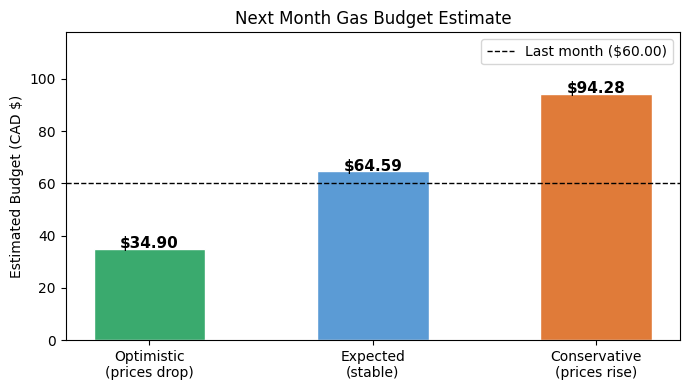

In [9]:
# Visualise budget range
fig, ax = plt.subplots(figsize=(7, 4))

labels  = ['Optimistic\n(prices drop)', 'Expected\n(stable)', 'Conservative\n(prices rise)']
budgets = [budget_low, budget_mid, budget_high]
colors  = ['#3aaa6e', '#5b9bd5', '#e07b39']

bars = ax.bar(labels, budgets, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, budgets):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'${val:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(last_month_spend, color='black', linestyle='--', linewidth=1,
           label=f'Last month (${last_month_spend:.2f})')
ax.set_ylabel('Estimated Budget (CAD $)')
ax.set_title('Next Month Gas Budget Estimate')
ax.legend()
ax.set_ylim(0, max(budgets) * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'budget_estimate.png'), dpi=150)
plt.show()

## 5. Export forecast to CSV

In [10]:
# Full 28-day daily forecast
forecast_df[['pred_low', 'pred_mid', 'pred_high', 'week']].to_csv(os.path.join(DATA_DIR, 'forecast_28day.csv'))
print('Saved: ../Data/forecast_28day.csv')

# Weekly summary
weekly.to_csv(os.path.join(DATA_DIR, 'forecast_weekly.csv'))
print('Saved: ../Data/forecast_weekly.csv')

# Budget estimate
pd.DataFrame([{
    'generated_on'        : datetime.today().date(),
    'last_month_spend'    : last_month_spend,
    'last_month_avg_price': round(last_month_avg, 2),
    'implied_litres'      : round(implied_litres, 1),
    'budget_optimistic'   : round(budget_low,  2),
    'budget_expected'     : round(budget_mid,  2),
    'budget_conservative' : round(budget_high, 2)
}]).to_csv(os.path.join(DATA_DIR, 'budget_estimate.csv'), index=False)
print('Saved: ../Data/budget_estimate.csv')

Saved: ../Data/forecast_28day.csv
Saved: ../Data/forecast_weekly.csv
Saved: ../Data/budget_estimate.csv


## 5b. Log today's prediction

Creates `predictions_log.csv` in `../Data/` on first run, then appends one row each time.
The History page in the web app reads from this file.
Fill in `actual_tomorrow` manually the next day to track real-world accuracy.

In [11]:
# ── Predictions log ──────────────────────────────────────────────────────────
PRED_LOG = os.path.join(DATA_DIR, 'predictions_log.csv')

# Get tomorrow's single-day prediction from both models
X_latest      = df.iloc[[-1]][FEATURES]
pred_ridge_val = round(float(ridge.predict(scaler.transform(X_latest))[0]), 2)
pred_lgbm_val  = round(float(lgbm.predict(X_latest)[0]), 2)
pred_ens_val   = round((pred_ridge_val + pred_lgbm_val) / 2, 2)

new_row = pd.DataFrame([{
    'prediction_made_on' : today_date.date(),
    'predicting_for'     : (today_date + pd.Timedelta(days=1)).date(),
    'actual_price_today' : round(float(today_price), 2),
    'pred_ridge'         : pred_ridge_val,
    'pred_lgbm'          : pred_lgbm_val,
    'pred_ensemble'      : pred_ens_val,
    'actual_tomorrow'    : None   # fill in manually once tomorrow's price is known
}])

if os.path.exists(PRED_LOG):
    log_df = pd.read_csv(PRED_LOG)
    # Avoid duplicate entries for the same prediction date
    log_df = log_df[log_df['prediction_made_on'] != str(today_date.date())]
    log_df = pd.concat([log_df, new_row], ignore_index=True)
else:
    log_df = new_row

log_df.to_csv(PRED_LOG, index=False)
print(f'Saved: ../Data/predictions_log.csv  ({len(log_df)} rows)')
print()
print(log_df.tail(3).to_string(index=False))

Saved: ../Data/predictions_log.csv  (1 rows)

prediction_made_on predicting_for  actual_price_today  pred_ridge  pred_lgbm  pred_ensemble actual_tomorrow
        2026-03-31     2026-04-01               193.1      196.15     187.96         192.06            None


## 6. Retrain function

The `retrain()` function below reloads the latest data, retrains both models on
**all available rows**, saves fresh `.pkl` files, and logs the run to `retrain_log.json`.

This is called automatically by `scheduler.py` — no manual intervention needed.

In [12]:
def retrain():
    """
    Retrain Ridge and LightGBM on all available data.
    Called daily by scheduler.py, or manually by uncommenting the last line.
    """
    print(f'[{datetime.now().strftime("%Y-%m-%d %H:%M")}] Starting retrain...')

    df_new = pd.read_csv(os.path.join(DATA_DIR, 'montreal_gas_ml_ready.csv'))
    date_col = 'date' if 'date' in df_new.columns else 'Unnamed: 0'
    df_new[date_col] = pd.to_datetime(df_new[date_col])
    df_new = df_new.set_index(date_col)
    df_new.index.name = 'date'

    EXCLUDE_RT  = ['gas_price', 'wti_usd', 'cadusd', 'wti_cad', 'target_price', 'target_change']
    FEATURES_RT = [c for c in df_new.columns if c not in EXCLUDE_RT]
    TARGET_RT   = 'target_price'

    df_train = df_new.dropna(subset=[TARGET_RT])
    X_rt = df_train[FEATURES_RT]
    y_rt = df_train[TARGET_RT]

    # Ridge
    sc_rt = StandardScaler()
    X_rt_scaled = sc_rt.fit_transform(X_rt)
    ridge_rt = Ridge(alpha=1.0)
    ridge_rt.fit(X_rt_scaled, y_rt)

    # LightGBM
    lgbm_rt = LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=4,
        num_leaves=15, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=10, random_state=42, verbose=-1
    )
    lgbm_rt.fit(X_rt, y_rt)

    # Save
    joblib.dump(ridge_rt, os.path.join(WEBAPP_DIR, 'model_ridge.pkl'))
    joblib.dump(lgbm_rt,  os.path.join(WEBAPP_DIR, 'model_lgbm.pkl'))
    joblib.dump(sc_rt,    os.path.join(WEBAPP_DIR, 'scaler.pkl'))

    # Log
    with open(os.path.join(WEBAPP_DIR, 'retrain_log.json'), 'w') as f:
        json.dump({
            'last_retrain'  : datetime.now().strftime('%Y-%m-%d %H:%M'),
            'training_rows' : len(df_train),
            'data_end'      : str(df_new.index.max().date()),
            'features'      : len(FEATURES_RT)
        }, f, indent=2)

    print(f'Retrain complete — {len(df_train):,} rows, data up to {df_new.index.max().date()}')
    print('Saved: model_ridge.pkl, model_lgbm.pkl, scaler.pkl, retrain_log.json')


# Uncomment to trigger a manual retrain right now:
retrain()

[2026-04-03 19:41] Starting retrain...
Retrain complete — 2,523 rows, data up to 2026-03-31
Saved: model_ridge.pkl, model_lgbm.pkl, scaler.pkl, retrain_log.json


## 7. How to use this notebook daily

**Auto-retraining (recommended):**
1. Run `scheduler.py` once in a terminal — it retrains every morning at 8:00 AM automatically
2. Re-run this notebook whenever you want an updated forecast

**Manual retraining:**
1. Re-run Notebooks 1 & 2 to update `montreal_gas_ml_ready.csv` with latest prices
2. Uncomment `retrain()` in Cell 6 and run it
3. Re-run this notebook to get fresh predictions

---

## 8. Next step — Web Application

This notebook is the engine behind the web app. The backend (Flask / FastAPI) will:
- Call the forecast and budget logic from this notebook
- Expose endpoints like `/forecast`, `/budget`, `/weekly`
- Trigger `retrain()` on a schedule

The frontend will display:
- 4-week price forecast chart
- Weekly price range cards
- Budget estimator with user input for last month's spend